# 第64课 · 亲手把 loss 压下去——训练评估闭环、混淆矩阵（confusion matrix）与过拟合诊断

**目标**：实现 `train_epoch` / `eval_accuracy`，把训练、验证和混淆矩阵连成一个能诊断问题的闭环。

> 通关标准不是只看 accuracy，而是同时看 train/val 走势和过拟合迹象（train 降、val 升）；接上 L62/L63 才是真端到端。

🔗 **Aurora 连接**：
- mel 特征由 `aurora.audio.mfcc`（STFT → mel filterbank → log）提供，详见 `src/aurora/audio/`
- 本课用假数据 + 小 MLP 演示训练循环骨架；换上真实的 `KeywordCNN`（L63）与 `KWSDataset`（L62）后，将成为 Aurora 项目第一个端到端训练的模型，后续推理模块直接加载其权重


← **上一课**　[L63 · 音频分类模型](L63_kws_model.ipynb)

> 上节课学习了 **音频分类模型**：CNN + Mel 特征，在 Speech Commands 上定义网络。  
> 本课将探讨 **训练评估闭环**。

## 本课剧情：为什么"看 loss 下降"不够，还要看混淆矩阵？

loss 下降只是表面，真正的问题是：模型到底在学什么，又在哪些类别上犯错？

**问题**：如果数据集里 "yes" 占 80%，模型只要每次都猜 "yes"，准确率就有 80%。但这根本不是真正的识别，是**样本不均衡**导致的假象。

**三个诊断工具**：

| 工具 | 看什么 | 发现什么问题 |
|---|---|---|
| 训练 loss | 模型是否在学习 | 过拟合（overfitting）/欠拟合 |
| 验证准确率 | 泛化能力 | 整体判断，但掩盖不均衡 |
| 混淆矩阵 | 每对 (真实,预测) 的样本数 | 哪些类互相混淆 |

**交叉熵损失**（`nn.CrossEntropyLoss`）：接受 logit（未经 softmax 的原始输出），内部自动算 softmax 再算 log loss：
```
CE = -log(softmax(logit)[y])    ← 正确类的对数概率取负
初始值 ≈ log(num_classes) = log(10) ≈ 2.3   ← 随机猜测的期望损失
```

**训练闭环 = 两个函数**：
```
train_epoch(model, loader, optimizer, criterion) → avg_loss
eval_accuracy(model, loader)                      → accuracy %
```

本节任务：实现这两个函数，让训练循环能在 5 轮内看到 loss 下降、准确率上升。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## 0.5 Softmax：把分数变成可比较的概率

在进入损失函数之前，先理解 softmax 这个"概率转换器"。

### 问题：为什么模型输出要转成概率？

当你训练一个分类器时，模型末层输出的数字叫 **logit**（原始分数）。比如说：
```
样本 x 通过模型 → [2.0, 0.5, -1.0]  （对应类别 "yes", "no", "stop" 的原始分数）
```

这三个数字没有明确含义——2.0 是什么意思？比 0.5 大两倍就是"确定性两倍"吗？为了让模型的输出 **易于理解和解释**，我们需要把这些分数转成"概率"（0 到 1 之间，加起来等于 1）。这样，0.7 就表示"70% 概率是 yes"。

### Softmax 是什么？它为什么用指数函数？

**Softmax 公式**：
```
softmax(logit)[j] = exp(logit[j]) / sum_k exp(logit[k])
```

分解这个公式：
- **分子** `exp(logit[j])` ：把第 j 个分数指数化
- **分母** `sum_k exp(logit[k])` ：所有分数的指数和（用于归一化）
- **结果**：一个介于 0 和 1 的数，所有类别加起来等于 1

**为什么要用指数函数 exp() 而不是直接用 logit / sum(logit)？**

让我们用对比来看。假设 logit = [2.0, 0.5, -1.0]：

1. **直接归一化**（logit / sum(logit)）：
   - 分母 = 2.0 + 0.5 + (-1.0) = 1.5
   - 结果 = [2.0/1.5, 0.5/1.5, -1.0/1.5] = [1.33, 0.33, -0.67]
   - ❌ 出现了**负数**！这不是概率（概率不能是负数）

2. **Softmax**（指数归一化）：
   - exp([2.0, 0.5, -1.0]) ≈ [7.39, 1.65, 0.37]（所有正数）
   - 分母 = 7.39 + 1.65 + 0.37 = 9.41
   - 结果 ≈ [0.785, 0.175, 0.040]（全是正数，加起来 = 1）
   - ✅ 完美的概率分布

**指数函数的妙处**：
- `exp(x)` 对所有 x 都返回**正数**（永远 > 0），所以结果永远是合法的概率
- **强化大的值**：logit 中的大值（如 2.0）经过 exp 会变成相对更大（exp(2.0) ≈ 7.39），强化了它的权重
- **压小的值**：logit 中的小值（如 -1.0）经过 exp 会很小（exp(-1.0) ≈ 0.37），几乎不影响结果

这样，logit 中相对大的分数会被解释为"这个类更可能"，这正是分类器想要的行为。

### 在交叉熵中的作用

将 logit 通过 softmax 转成概率后，损失函数会取**正确类的概率的负对数**：
```
CE = -log(softmax(logit)[正确类])
```

这样：
- 模型**越确定**（softmax 越接近 1）→ log 越接近 0 → 损失越小 ✅
- 模型**越不确定**（softmax 越接近 0）→ log 越接近 -∞ → 损失巨大 ❌

完全学到位了。

## 1. 交叉熵损失 与 Adam 优化器

**交叉熵损失**（`nn.CrossEntropyLoss`）输入原始 logit（形状 `[B, C]`）和整数标签（形状 `[B]`），内部做 softmax 再取负对数似然：

```
loss = -log( exp(logit[y]) / sum_j exp(logit[j]) )
```

不要在模型末尾手动加 softmax——`CrossEntropyLoss` 已经包含了。

**Adam 优化器** 结合了动量（一阶矩）和自适应学习率（二阶矩）。关键词识别（keyword spotting，KWS）任务通常以学习率 `lr=1e-3` 作为起点。

```python
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
```

In [3]:
# 演示 Softmax 的转换效果
import torch.nn.functional as F

# 三个样本的 logit（模型原始输出）
logits_demo = torch.tensor([
    [2.0, 0.5, -1.0],   # 样本1：有信心是类0
    [0.3, 0.3, 0.3],    # 样本2：完全不确定
    [-2.0, -0.5, 1.5]   # 样本3：有信心是类2
], dtype=torch.float32)

print("原始 logit（模型输出）:")
print(logits_demo)
print()

# 手算一遍 softmax（以第一个样本为例）
sample_0_logit = logits_demo[0]  # [2.0, 0.5, -1.0]
exp_vals = torch.exp(sample_0_logit)
softmax_manual = exp_vals / exp_vals.sum()
print(f"样本0的 logit = {sample_0_logit.tolist()}")
print(f"  exp 后 = {exp_vals.tolist()}")
print(f"  归一化后 (softmax) = {softmax_manual.tolist()}")
print(f"  验证加起来 = {softmax_manual.sum().item():.6f}")
print()

# 用 PyTorch 内置的 softmax（结果应该一样）
probs = F.softmax(logits_demo, dim=1)
print("所有样本经过 softmax 后的概率分布:")
print(probs)
print()

# 解读这些概率
for i, prob_i in enumerate(probs):
    most_likely = prob_i.argmax().item()
    confidence = prob_i[most_likely].item()
    print(f"样本{i}: 最可能是类{most_likely}，置信度 {confidence:.1%}")


原始 logit（模型输出）:
tensor([[ 2.0000,  0.5000, -1.0000],
        [ 0.3000,  0.3000,  0.3000],
        [-2.0000, -0.5000,  1.5000]])

样本0的 logit = [2.0, 0.5, -1.0]
  exp 后 = [7.389056205749512, 1.6487212181091309, 0.3678794503211975]
  归一化后 (softmax) = [0.785597026348114, 0.17529039084911346, 0.039112575352191925]
  验证加起来 = 1.000000

所有样本经过 softmax 后的概率分布:
tensor([[0.7856, 0.1753, 0.0391],
        [0.3333, 0.3333, 0.3333],
        [0.0259, 0.1161, 0.8580]])

样本0: 最可能是类0，置信度 78.6%
样本1: 最可能是类0，置信度 33.3%
样本2: 最可能是类2，置信度 85.8%


In [4]:
# 演示：CrossEntropyLoss 的行为
criterion_demo = nn.CrossEntropyLoss()

# 3 个样本，4 类
logits = torch.tensor([[2.0, 0.5, 0.1, 0.1],   # 自信预测类 0
                        [0.1, 0.1, 2.0, 0.1],   # 自信预测类 2
                        [0.5, 0.5, 0.5, 0.5]])  # 完全不确定
labels = torch.tensor([0, 2, 1])  # 真实标签

loss_val = criterion_demo(logits, labels)
print(f'损失值: {loss_val.item():.4f}')
print('前两个样本预测正确且自信 → 损失小；第三个不确定且错误 → 损失大')

损失值: 0.7257
前两个样本预测正确且自信 → 损失小；第三个不确定且错误 → 损失大


In [5]:
# 深入理解：为什么初始化的 loss ≈ log(num_classes)？
import torch
import torch.nn as nn

print("=" * 60)
print("初始化模型的交叉熵损失 = log(类别数)？")
print("=" * 60)

num_classes = 10
criterion = nn.CrossEntropyLoss()

# 场景1：完全随机初始化（logit 都很小且接近）
torch.manual_seed(42)
random_logits = torch.randn(1000, num_classes) * 0.01  # N(0, 0.01)，很小
random_labels = torch.randint(0, num_classes, (1000,))
loss_random = criterion(random_logits, random_labels)

print(f"\n场景1：随机初始化（高斯 N(0, 0.01)）")
print(f"  1000个样本的平均损失 = {loss_random.item():.4f}")
print(f"  log(10) = {torch.log(torch.tensor(10.0)).item():.4f}")
print(f"  ✅ 基本相等！")

# 场景2：逐步分析为什么
print(f"\n场景2：为什么是 log(num_classes)？")
print(f"  当所有 logit 都接近 0 时：")
print(f"    exp(0) = 1")
print(f"    softmax[j] = 1 / (1 + 1 + ... + 1)  （共10个1）")
print(f"             = 1 / 10 = 0.1")
print(f"    CE = -log(0.1) = -log(1/10) = log(10) = {torch.log(torch.tensor(10.0)).item():.4f}")

# 场景3：理解"随机猜测"的含义
print(f"\n场景3：比较与真实标签的损失")
correct_labels = torch.zeros(1000, dtype=torch.long)  # 都标记为类0
loss_correct = criterion(random_logits, correct_labels)
print(f"  即使随机初始化，若标签都是 0，CE 仍约 {loss_correct.item():.4f}")
print(f"  这是因为随机初始化模型对所有类等概率，错猜类0的概率也是 1/10")

# 场景4：训练后的改进
print(f"\n场景4：训练会把损失压下来")
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(100, 50),
    nn.ReLU(),
    nn.Linear(50, num_classes)
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 一个超简单的数据集：128个样本，特征维100，标签随机
X_simple = torch.randn(128, 100)
y_simple = torch.randint(0, num_classes, (128,))

loss_before = criterion(model(X_simple), y_simple).item()
print(f"  训练前损失 = {loss_before:.4f}")

# 训练50步
for _ in range(50):
    optimizer.zero_grad()
    logits = model(X_simple)
    loss = criterion(logits, y_simple)
    loss.backward()
    optimizer.step()

loss_after = criterion(model(X_simple), y_simple).item()
print(f"  训练50步后损失 = {loss_after:.4f}")
print(f"  ✅ 损失从 {loss_before:.4f} → {loss_after:.4f}，压低了！")


初始化模型的交叉熵损失 = log(类别数)？

场景1：随机初始化（高斯 N(0, 0.01)）
  1000个样本的平均损失 = 2.3024
  log(10) = 2.3026
  ✅ 基本相等！

场景2：为什么是 log(num_classes)？
  当所有 logit 都接近 0 时：
    exp(0) = 1
    softmax[j] = 1 / (1 + 1 + ... + 1)  （共10个1）
             = 1 / 10 = 0.1
    CE = -log(0.1) = -log(1/10) = log(10) = 2.3026

场景3：比较与真实标签的损失
  即使随机初始化，若标签都是 0，CE 仍约 2.3032
  这是因为随机初始化模型对所有类等概率，错猜类0的概率也是 1/10

场景4：训练会把损失压下来
  训练前损失 = 2.3428
  训练50步后损失 = 0.0004
  ✅ 损失从 2.3428 → 0.0004，压低了！


## 2. Per-class Accuracy（每类准确率）

整体准确率 `correct / total` 掩盖了类别不均衡的问题。Per-class accuracy 分别统计每个关键词类别：

```
accuracy_c = (预测为 c 且真实为 c 的样本数) / (真实为 c 的样本总数)
```

如果某类占数据集 1%，整体 99% 准确率可能完全靠忽略它得到；per-class 准确率会暴露这个问题。

In [6]:
# 演示：手动计算 per-class accuracy
y_true = torch.tensor([0, 0, 1, 1, 2, 2, 2])
y_pred = torch.tensor([0, 1, 1, 1, 0, 2, 2])  # 类0预测错一个，类2预测错一个

num_classes = 3
for c in range(num_classes):
    mask = (y_true == c)
    acc_c = (y_pred[mask] == c).float().mean().item()
    print(f'  类 {c}: {acc_c:.2%}')

overall = (y_pred == y_true).float().mean().item()
print(f'整体准确率: {overall:.2%}')

  类 0: 50.00%
  类 1: 100.00%
  类 2: 66.67%
整体准确率: 71.43%


## 3. 混淆矩阵

混淆矩阵（confusion matrix，CM） `C` 的形状为 `[num_classes, num_classes]`：

```
C[i][j] = 真实标签为 i、预测为 j 的样本数
```

- **对角线** `C[i][i]`：正确预测
- **非对角线** `C[i][j]`（i≠j）：错误预测（把类 i 误判为类 j）

用热力图可视化时，颜色越深代表该格样本越多；理想情况下热力图只有对角线是深色的。

混淆矩阵:
[[1 1 0]
 [0 2 0]
 [1 0 2]]


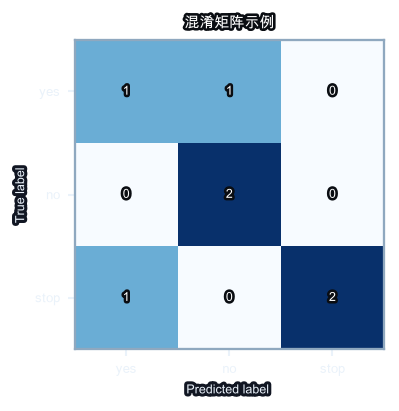

In [7]:
# 演示：用 sklearn 计算并可视化混淆矩阵
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_np = y_true.numpy()
y_pred_np = y_pred.numpy()
class_names = ['yes', 'no', 'stop']

cm = confusion_matrix(y_true_np, y_pred_np)
print('混淆矩阵:')
print(cm)

fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('混淆矩阵示例')
plt.tight_layout()
plt.show()

In [8]:
# 混淆矩阵热力图的颜色说明
print("\n热力图颜色解读：")
print(f"  颜色越深（蓝色越深）→ 这个格子里的样本数越多")
print(f"  颜色越浅（接近白色）→ 这个格子里的样本数越少")
print()
print(f"理想情况：")
print(f"  ✅ 对角线 C[i][i] 很深（预测正确的样本多）")
print(f"  ✅ 非对角线都很浅（预测错误的样本少）")
print()
print(f"这样的热力图看起来是这样：")
print(f"  深蓝色的对角线贯穿矩阵")
print(f"  四周都是白色或淡蓝色")



热力图颜色解读：
  颜色越深（蓝色越深）→ 这个格子里的样本数越多
  颜色越浅（接近白色）→ 这个格子里的样本数越少

理想情况：
  ✅ 对角线 C[i][i] 很深（预测正确的样本多）
  ✅ 非对角线都很浅（预测错误的样本少）

这样的热力图看起来是这样：
  深蓝色的对角线贯穿矩阵
  四周都是白色或淡蓝色


## 3.5 model.train() 和 model.eval()：神经网络的两种工作模式

你可能注意到，在训练循环中有两句神秘的命令：
```python
model.train()   # 训练时
model.eval()    # 评估时
```

这两句到底做什么？为什么必须分开？让我们从两个特殊层开始。

### Dropout：训练时的"随机丢弃"

**问题**：当一个神经网络在训练集上训练得很好时，有时候会"过度依赖"某些特定的神经元或特征组合。换个数据集就不行了——这叫**过拟合**。

**Dropout 的想法**：训练时，随机关闭一些神经元（概率为 `p`，比如 50%），这样网络被迫学会"多条路线"来完成任务。类比一下：

> 假设你记笔记时总是用同一支笔的同一种蓝色。有一天那支笔丢了，你就抓瞎了。但如果你训练的时候经常随机换笔（有时蓝色、有时黑色、有时没笔），你会学会用多种方式理解内容。真正考试时，再用什么笔都能做得好。

代码示例：
```python
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(100, 50)
        self.dropout = nn.Dropout(p=0.5)  # 50% 概率丢弃
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.dropout(x)      # ← 这里会随机丢弃
        x = self.fc2(x)
        return x

model = Model()

# 训练时：Dropout 随机丢弃
model.train()
for _ in range(100):
    logits = model(x_train)  # 每次前向传播，不同的神经元被丢弃
    # ...

# 评估时：Dropout 保留所有神经元
model.eval()
with torch.no_grad():
    logits = model(x_val)    # 每个神经元都被使用（但会自动缩放）
```

**Train vs Eval 模式的区别**：
- `model.train()`：Dropout 以概率 `p` 随机丢弃神经元（以及对应的权重）
- `model.eval()`：Dropout 全部保留，但会自动缩放输出（乘以 `1/(1-p)`），使期望不变

### BatchNorm：训练时的"数据归一化"

**问题**：神经网络中间层的输入分布会随着权重更新而不断变化（叫做 internal covariate shift），导致训练不稳定。

**BatchNorm 的想法**：每个中间层都对当前 batch 的数据做**归一化**（减去 mean，除以 std），这样数据始终保持在合理的范围内。

```python
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(100, 50)
        self.bn1 = nn.BatchNorm1d(50)  # BN 层
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)   # ← 这里计算 mean/std
        x = torch.relu(x)
        x = self.fc2(x)
        return x
```

**Train vs Eval 模式的核心区别**：

| 工作模式 | 计算方式 | 原因 |
|---|---|---|
| **训练** (`model.train()`) | 用当前 batch 的 mean/std 归一化 | batch 反映数据的当前特性，更新权重时需要"刚好"的归一化 |
| **评估** (`model.eval()`) | 用全局 running mean/std 归一化 | 评估集可能只有几十个样本，无法代表整体分布；改用训练过程中积累的全局统计量 |

**类比**：
> 水温显示器：训练时，每个 batch 都是一杯新水，用它的温度表示这杯水的"正常"。评估时，你没有足够的水样本，所以用过去积累的平均温度。

### 为什么既要 model.eval() 又要 torch.no_grad()？

你可能看到过这样的代码：
```python
model.eval()
with torch.no_grad():
    predictions = model(x_test)
```

两行都需要吗？

- **`model.eval()`**：关闭 Dropout（保留所有神经元）、告诉 BatchNorm 用 running statistics。但**梯度计算依然打开**。
- **`torch.no_grad()`**：禁止自动求导，节省显存和计算时间。

所以它们各司其职：
- `eval()` 改变网络的**行为**（Dropout、BatchNorm 的工作方式）
- `no_grad()` 改变 PyTorch 的**计算模式**（不构建计算图）

如果只用 `model.eval()` 而不用 `no_grad()`，代码仍能跑，但会浪费显存；如果只用 `no_grad()` 而不用 `eval()`，Dropout 还会继续随机丢弃，评估结果就不对了。

## 4. ✏️ 实现 `train_epoch(model, loader, optimizer, criterion)`

**5步实现（每个 batch 重复）**：

| 步骤 | 操作 | 注意 |
|---|---|---|
| 1 | `model.train()` | 开启 dropout/BN 训练模式（放在 epoch 开始） |
| 2 | `optimizer.zero_grad()` | 清零梯度，每 batch 必须执行 |
| 3 | `loss = criterion(model(x), y)` | 前向 + 计算 loss |
| 4 | `loss.backward()` | 反向传播 |
| 5 | `optimizer.step()` | 更新参数 |

**返回值**：`avg_loss: float` = 所有 batch 的平均损失

**验收标准**：
- 函数返回 float，不是 Tensor
- 多次调用 loss 应下降（对合理的 lr 和数据）

In [9]:
# 为什么必须 zero_grad()？反面教材
print("=" * 60)
print("演示：忘记 zero_grad() 的后果")
print("=" * 60)

torch.manual_seed(0)
model_bad = nn.Linear(3, 1)  # 简单模型，3输入，1输出
optimizer_bad = torch.optim.SGD(model_bad.parameters(), lr=0.1)
criterion_bad = nn.MSELoss()

# 故意不 zero_grad()
x_demo = torch.tensor([[1.0, 2.0, 3.0], [2.0, 3.0, 4.0]])
y_demo = torch.tensor([[1.0], [2.0]])

print("\n【错误做法】不清零梯度：")
for i in range(3):
    out = model_bad(x_demo)
    loss = criterion_bad(out, y_demo)
    loss.backward()
    # ❌ 没有 optimizer.zero_grad()
    optimizer_bad.step()
    print(f"  Epoch {i+1}: loss={loss.item():.4f}, 权重={model_bad.weight.data[0, 0].item():.4f}, "
          f"梯度={model_bad.weight.grad[0, 0].item():.4f}")

print("\n分析：梯度在累积！第1轮梯度 g1，第2轮是 g2+g1，第3轮是 g3+g2+g1")
print("这导致 step() 更新时用了错误的梯度方向，权重跳跃不稳定。")

print("\n【正确做法】每轮清零梯度：")
torch.manual_seed(0)
model_good = nn.Linear(3, 1)
optimizer_good = torch.optim.SGD(model_good.parameters(), lr=0.1)
criterion_good = nn.MSELoss()

for i in range(3):
    optimizer_good.zero_grad()  # ✅ 先清零
    out = model_good(x_demo)
    loss = criterion_good(out, y_demo)
    loss.backward()
    optimizer_good.step()
    print(f"  Epoch {i+1}: loss={loss.item():.4f}, 权重={model_good.weight.data[0, 0].item():.4f}, "
          f"梯度={model_good.weight.grad[0, 0].item():.4f}")

print("\n✅ 正确做法中，每轮的梯度都是独立计算的，权重更新稳定。")

演示：忘记 zero_grad() 的后果

【错误做法】不清零梯度：
  Epoch 1: loss=8.2958, 权重=0.9002, 梯度=-9.0456
  Epoch 2: loss=100.3602, 权重=-1.3229, 梯度=22.2318
  Epoch 3: loss=482.4240, 权重=3.3255, 梯度=-46.4842

分析：梯度在累积！第1轮梯度 g1，第2轮是 g2+g1，第3轮是 g3+g2+g1
这导致 step() 更新时用了错误的梯度方向，权重跳跃不稳定。

【正确做法】每轮清零梯度：
  Epoch 1: loss=8.2958, 权重=0.9002, 梯度=-9.0456
  Epoch 2: loss=100.3602, 权重=-2.2275, 梯度=31.2774
  Epoch 3: loss=1215.2433, 权重=8.6764, 梯度=-109.0391

✅ 正确做法中，每轮的梯度都是独立计算的，权重更新稳定。


In [10]:
def train_epoch(model, loader, optimizer, criterion):
    """训练一个 epoch，返回平均损失。"""
    # ✏️ TODO: model.train()
    # ✏️ TODO: for x, y in loader:
    #              optimizer.zero_grad()
    #              out = model(x)
    #              loss = criterion(out, y)
    #              loss.backward()
    #              optimizer.step()
    #              累积 loss.item()
    # ✏️ TODO: return avg_loss
    raise NotImplementedError

In [11]:
# 目视验证 train_epoch
# 用一个极小的假模型 + 假 loader 快速冒烟测试
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
_x = torch.randn(16, 1, 40, 32)   # 16 个样本，单通道 mel 图
_y = torch.randint(0, 4, (16,))   # 4 类随机标签
_loader = DataLoader(TensorDataset(_x, _y), batch_size=8)

_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(40*32, 4)
)
_opt = torch.optim.Adam(_model.parameters(), lr=1e-3)
_crit = nn.CrossEntropyLoss()

try:
    _loss = train_epoch(_model, _loader, _opt, _crit)
    assert isinstance(_loss, float), '返回值应为 float'
    assert _loss > 0, '损失应大于 0'
    print(f'✅ train_epoch 通过，avg_loss = {_loss:.4f}')

    # 增强验证：确认权重确实被更新（第 2 epoch 损失应低于第 1 epoch）
    _loss_e2 = train_epoch(_model, _loader, _opt, _crit)
    assert _loss_e2 < _loss, (
        f'第 2 epoch 损失({_loss_e2:.4f})应小于第 1 epoch({_loss:.4f})；'
        '请检查 optimizer.step() 是否被正确调用，以及 zero_grad() 是否在每批前执行'
    )
    print(f'✅ 权重更新验证通过：epoch1={_loss:.4f} → epoch2={_loss_e2:.4f}')
except (NotImplementedError, TypeError):
    print('⚠️ train_epoch 尚未实现——完成第 4 节 TODO 后重新运行此 cell')

⚠️ train_epoch 尚未实现——完成第 4 节 TODO 后重新运行此 cell


## 4.5 argmax(dim=1)：从分数到类别预测

在评估准确率时，我们需要把模型的输出（每个类的打分）转换成"这个样本属于哪一类"。这就是 `argmax` 做的事。

### 模型输出的形状

先看一个实际例子。假设你有：
- **10 个样本**（batch）
- **4 个类别**（比如 "yes", "no", "stop", "go"）

模型通过这 10 个样本，输出一个形状为 `(10, 4)` 的张量（10 行，4 列）：

```
样本\类别    是否    否      停止    出发
0         [2.5,  0.1,  -1.2,  0.3]   ← 样本0对4个类的打分
1         [0.2,  3.1,   0.5,  1.0]   ← 样本1对4个类的打分
2         [-0.1, 1.5,   2.8,  0.2]   ← 样本2对4个类的打分
...
9         [1.0,  0.5,   0.5,  1.5]   ← 样本9对4个类的打分
```

每一**行**（第 i 个样本）都是一个长度为 4 的向量，表示这个样本对 4 个类的"打分"（logit）。

### argmax(dim=1) 的含义

`argmax(dim=1)` 沿着第 1 维（列方向）取最大值的**索引**：

```python
logits = torch.tensor([
    [2.5, 0.1, -1.2, 0.3],   # 样本0：最大是 2.5（在索引0）→ 预测类0
    [0.2, 3.1, 0.5, 1.0],    # 样本1：最大是 3.1（在索引1）→ 预测类1
    [-0.1, 1.5, 2.8, 0.2],   # 样本2：最大是 2.8（在索引2）→ 预测类2
])

preds = logits.argmax(dim=1)
# 结果：tensor([0, 1, 2])
```

**为什么这样做？** 因为 logit 越大，softmax 后对应的概率越大（通过指数函数被"放大"）。所以打分最高的类就是模型最有信心预测的类。

### 对比其他维度

如果你误用了 `dim=0` 会怎样？

```python
preds_wrong = logits.argmax(dim=0)
# 结果：tensor([0, 1, 2, 1])
# 这是说：第0类中打分最高的是样本0，第1类中打分最高的是样本1……
# ❌ 这不是我们要的！我们要的是"每个样本属于哪一类"，不是"每个类来自哪个样本"。
```

In [12]:
# 演示 argmax(dim=1) 的用法
print("=" * 60)
print("argmax(dim=1)：从打分到预测类别")
print("=" * 60)

logits_example = torch.tensor([
    [2.5, 0.1, -1.2, 0.3],    # 样本0
    [0.2, 3.1, 0.5, 1.0],     # 样本1
    [-0.1, 1.5, 2.8, 0.2],    # 样本2
    [1.0, 1.0, 1.0, 2.5],     # 样本3
], dtype=torch.float32)

class_names = ['yes', 'no', 'stop', 'go']
print(f"\nLogits 张量形状: {logits_example.shape}  (4个样本, 4个类别)")
print(f"Logits 内容:")
print(logits_example)

# 沿 dim=1 取最大值的索引
preds = logits_example.argmax(dim=1)
print(f"\nargmax(dim=1) 结果: {preds.tolist()}")

# 解释每个预测
print(f"\n逐个解释：")
for i, (logit_row, pred_idx) in enumerate(zip(logits_example, preds)):
    max_score = logit_row[pred_idx].item()
    pred_class = class_names[pred_idx]
    print(f"  样本{i}: 打分={logit_row.tolist()}")
    print(f"         最大值 {max_score:.2f} 在索引{pred_idx} → 预测 '{pred_class}'")

# 错误示范：用 dim=0
print(f"\n【错误】如果用 argmax(dim=0)：")
preds_wrong = logits_example.argmax(dim=0)
print(f"结果: {preds_wrong.tolist()}")
print(f"解释：这是说\"第0类中打分最高的是样本 {preds_wrong[0]}，第1类中打分最高的是样本 {preds_wrong[1]}\"")
print(f"❌ 这不是我们要的！")


argmax(dim=1)：从打分到预测类别

Logits 张量形状: torch.Size([4, 4])  (4个样本, 4个类别)
Logits 内容:
tensor([[ 2.5000,  0.1000, -1.2000,  0.3000],
        [ 0.2000,  3.1000,  0.5000,  1.0000],
        [-0.1000,  1.5000,  2.8000,  0.2000],
        [ 1.0000,  1.0000,  1.0000,  2.5000]])

argmax(dim=1) 结果: [0, 1, 2, 3]

逐个解释：
  样本0: 打分=[2.5, 0.10000000149011612, -1.2000000476837158, 0.30000001192092896]
         最大值 2.50 在索引0 → 预测 'yes'
  样本1: 打分=[0.20000000298023224, 3.0999999046325684, 0.5, 1.0]
         最大值 3.10 在索引1 → 预测 'no'
  样本2: 打分=[-0.10000000149011612, 1.5, 2.799999952316284, 0.20000000298023224]
         最大值 2.80 在索引2 → 预测 'stop'
  样本3: 打分=[1.0, 1.0, 1.0, 2.5]
         最大值 2.50 在索引3 → 预测 'go'

【错误】如果用 argmax(dim=0)：
结果: [0, 1, 2, 3]
解释：这是说"第0类中打分最高的是样本 0，第1类中打分最高的是样本 1"
❌ 这不是我们要的！


## 5. ✏️ 实现 `eval_accuracy(model, loader)`

**3步实现**：

| 步骤 | 操作 | 关键细节 |
|---|---|---|
| 1 | `model.eval()` + `torch.no_grad():` | 关闭 dropout，禁止梯度计算（省显存）|
| 2 | `preds = model(x).argmax(dim=1)` | logit 最大值索引 = 预测类别 |
| 3 | `correct += (preds == y).sum()` | 累积正确数，最后 / total |

**返回值**：`accuracy: float` ∈ [0.0, 1.0]

**验收标准**：
- 返回 float（不是 Tensor）
- 随机初始化时 ≈ 1/num_classes（随机猜测）
- 训练后应 > 随机基线

In [13]:
def eval_accuracy(model, loader):
    """在验证集上计算整体准确率。"""
    # ✏️ TODO: model.eval()
    # ✏️ TODO: with torch.no_grad():
    #              for x, y in loader:
    #                  preds = model(x).argmax(dim=1)
    #                  累积 correct / total
    # ✏️ TODO: return correct / total
    raise NotImplementedError

In [14]:
# 目视验证 eval_accuracy
try:
    _acc_before = eval_accuracy(_model, _loader)
    assert 0.0 <= _acc_before <= 1.0, '准确率应在 [0, 1]'
    print(f'✅ eval_accuracy 通过，准确率 = {_acc_before:.2%}')

    # 增强验证：边界检查——完美预测模型应返回准确率 1.0
    _bnd_x = torch.zeros(4, 1, 40, 32)
    _bnd_y = torch.tensor([0, 1, 2, 3])
    _bnd_loader = DataLoader(TensorDataset(_bnd_x, _bnd_y), batch_size=4)

    class _PerfectClassifier(nn.Module):
        """总是正确预测的占位模型：第 i 个样本预测类 i。"""
        def forward(self, x):
            # 4 样本 4 类，torch.eye(4) 使每个样本的正确类 logit 最大
            return torch.eye(4)

    _acc_perfect = eval_accuracy(_PerfectClassifier(), _bnd_loader)
    assert abs(_acc_perfect - 1.0) < 1e-6, (
        f'完美预测应返回 1.0，实际得到 {_acc_perfect:.4f}；'
        '请检查 (preds == y).sum() 的统计逻辑'
    )
    print(f'✅ 边界检查通过：完美预测准确率 = {_acc_perfect:.2%}')
except (NotImplementedError, TypeError):
    print('⚠️ eval_accuracy 尚未实现——完成第 5 节 TODO 后重新运行此 cell')

⚠️ eval_accuracy 尚未实现——完成第 5 节 TODO 后重新运行此 cell


## 5.5 过拟合（Overfitting）与泛化间隔

你可能听过"过拟合"这个词，但它到底指什么？为什么需要独立的训练集和验证集？

### 什么是过拟合？

用一个真实的故事理解：

> 高考前，有两个学生。
>
> **学生 A**（过拟合）：他拿到了往年 5 套真题，背得滚瓜烂熟。考试时，这 5 套题就算在原字不动换个数字，他也能秒做。但考试题是全新的（虽然考察的是同样的知识点），他抓瞎了——得分 60 分。
>
> **学生 B**（泛化）：他深入理解了概念，做过各种变式题，知道"为什么"而不是"怎么做"。考试时，虽然没见过这些确切的题，但他能灵活应用知识——得分 85 分。
>
> 考场外，朋友问学生 A："你在往年真题上都做对了啊？" 学生 A 说："是啊，我 100 分。但新题就不行了。"——这就是**过拟合**：在训练数据（往年真题）上表现完美，但在新数据（新题）上表现差。

### 如何诊断过拟合？需要两条曲线

你需要分别记录：
1. **训练集损失曲线**（Training Loss）：模型在用来训练的数据上的损失
2. **验证集准确率曲线**（Validation Accuracy）：模型在独立验证集上的准确率

**过拟合的症状**（两条曲线的"间隔"）：
```
训练损失：2.3 → 1.5 → 0.8 → 0.5 → 0.3 → 0.2（持续下降）
验证准确率：25% → 50% → 70% → 75% → 76% → 76%（趋于平稳）
                                    ↑ 这里开始不再上升
```

- 前期（第 1-3 轮）：训练和验证都在进步 ✅
- 后期（第 4-5 轮）：训练继续改进，但验证停滞 ⚠️ **过拟合开始**
  - 模型在"死记硬背"训练数据中的细节
  - 这些细节对新数据没有帮助

### 为什么要用独立的验证集？

试想，如果训练集 = 验证集（同一份数据）会怎样？

```
模型看过这些数据，可以完全记住：
  样本 A：输入 x_A → 标签 y_A ✓
  样本 B：输入 x_B → 标签 y_B ✓
  ……

验证时用同样的数据：
  样本 A：输入 x_A → 模型输出 y_A （因为记住了）✓
  样本 B：输入 x_B → 模型输出 y_B （因为记住了）✓
  ……

结果：训练准确率 = 验证准确率 = 100%

但这只证明了模型能"记住"，不证明它能"理解"和"泛化"！
```

**独立验证集的意义**：
- 验证集上的数据模型**从未见过**（没用来训练）
- 模型无法"死记"，只能依靠真实学到的规律
- 两条曲线的"间隔"才能真实反映过拟合程度

### "泛化间隔"的定义

**泛化间隔** = 验证性能 - 训练性能（或相反，取决于你看哪个指标）

```
泛化间隔 = 训练损失 - 验证损失  （理想 < 0.1）
       或
泛化间隔 = 训练准确率 - 验证准确率  （理想接近 0）
```

- 间隔 = 0：完美泛化（有点不现实）
- 间隔 < 0.1：很好的泛化
- 间隔 > 0.2：明显过拟合，需要采取措施（如 Dropout、L2 正则化、更多训练数据）

### 下一步：如何防止或诊断过拟合？

在本课（L64）你已经学会了用**独立验证集**来**观察**过拟合。下一课（L65）将教你如何用**可视化工具**（梯度直方图、权重分布等）来**诊断**过拟合的原因，以及用 **early stopping** 等技巧来**抑制**它。

## 6. 参数实验：训练曲线 + 混淆矩阵

**实验参数**：
- `num_epochs = 5`：观察损失从初始值（≈log(num_classes)≈1.39）下降的曲线形状
- `lr = 1e-3`（Adam 默认）：可改为 `1e-4` 对比收敛速度
- `batch_size = 8`：小批量训练，损失曲线会有抖动

**预期现象**：
- 损失曲线前 2 epoch 下降最快，之后趋于平缓
- 混淆矩阵对角线逐渐变深，非对角线变淡
- 若某两类混淆严重（非对角格颜色深），说明它们的 mel 特征相似，可能需要更多训练数据或更深的网络

In [15]:
# 参数实验：5 epoch 训练曲线 + 混淆矩阵
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 重新初始化模型（用假数据演示，替换为真实 KeywordCNN + DataLoader 即可）
torch.manual_seed(0)
exp_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(40*32, 64),
    nn.ReLU(),
    nn.Linear(64, 4)
)
exp_opt = torch.optim.Adam(exp_model.parameters(), lr=1e-3)
exp_crit = nn.CrossEntropyLoss()

# 假数据 loader（真实使用时替换为 SpeechCommandsDataset 的 DataLoader）
torch.manual_seed(1)
_x_big = torch.randn(128, 1, 40, 32)
_y_big = torch.randint(0, 4, (128,))
# ✅ 正确做法：用 random_split 把数据集切成独立的训练集和验证集
# 若 val_loader 和 train_loader 使用同一份数据，"验证准确率"等于训练准确率，
# 模型永远无法展示泛化间隔，过拟合诊断也就无从谈起。
from torch.utils.data import random_split
_full_ds = TensorDataset(_x_big, _y_big)
_train_ds, _val_ds = random_split(_full_ds, [100, 28],
                                  generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(_train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(_val_ds,   batch_size=16)

num_epochs = 5
train_losses = []
val_accs = []

try:
    for epoch in range(1, num_epochs + 1):
        loss = train_epoch(exp_model, train_loader, exp_opt, exp_crit)
        acc  = eval_accuracy(exp_model, val_loader)
        train_losses.append(loss)
        val_accs.append(acc)
        print(f'Epoch {epoch}/{num_epochs}  loss={loss:.4f}  acc={acc:.2%}')
except (NotImplementedError, TypeError):
    print('⚠️ train_epoch / eval_accuracy 尚未实现——完成第 4、5 节 TODO 后重新运行此 cell')

if train_losses:
    # 画训练曲线
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(range(1, num_epochs+1), train_losses, marker='o', color='steelblue')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title('训练损失曲线')
    axes[0].grid(alpha=0.3)

    axes[1].plot(range(1, num_epochs+1), val_accs, marker='s', color='tomato')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('验证准确率曲线')
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 混淆矩阵
    exp_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            all_preds.append(exp_model(xb).argmax(dim=1))
            all_labels.append(yb)
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    cm = confusion_matrix(all_labels, all_preds)
    class_names = ['yes', 'no', 'stop', 'go']

    fig2, ax2 = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax2, colorbar=True, cmap='Blues')
    ax2.set_title('验证集混淆矩阵（5 epoch 后）')
    plt.tight_layout()
    plt.show()

⚠️ train_epoch / eval_accuracy 尚未实现——完成第 4、5 节 TODO 后重新运行此 cell


## 本课收束

本节实现了 `train_epoch`（返回 `avg_loss: float`）和 `eval_accuracy`（返回 `accuracy: float`），并用假数据（`torch.randn` + 小 MLP）跑通了监督训练闭环的完整骨架——把模型换成 L63 的 `KeywordCNN`、数据换成 L62 的 `KWSDataset`（其 mel 特征由 `aurora.audio`（`src/aurora/audio/`）中的手写 STFT → mel filterbank 流水线提供），即得到 Aurora 项目第一个端到端训练的神经网络。下一节（L65）将对训练过程做深度可视化：实时绘制 Loss/Acc 曲线、监控梯度范数与权重分布直方图，帮助诊断过拟合、梯度消失等常见训练问题。

> **关于过拟合诊断范围**：本课（L64）通过独立验证集（cell-16 的 `random_split`）建立了观察过拟合的基础结构——训练损失持续下降而验证准确率趋于平稳。L65 将提供系统量化工具（early stopping 判据、梯度范数监控等），两课合看完整覆盖"过拟合介绍 → 深度诊断"链路。

## ✏️ 白板挑战：训练评估闭环手推（目标 10 分钟）

盖上屏幕，纸上推导：

**问 1**：`nn.CrossEntropyLoss` 随机初始化模型时期望损失是多少？（10类分类）  
（log(10)≈2.303，softmax输出≈均匀分布，每类概率≈0.1，-log(0.1)=2.303）

**问 2**：为什么 `eval_accuracy` 必须用 `torch.no_grad()` 而 `train_epoch` 不用？  
（推理不需要梯度，no_grad减少显存占用和计算量；训练需要梯度用于backward）

**问 3**：`model.train()` 和 `model.eval()` 对哪些层有影响？  
（Dropout: train时随机丢弃，eval时全部保留；BatchNorm: train用batch统计，eval用running mean/var）

**问 4**：混淆矩阵 `C[i][j]` 的含义是什么？对角线代表什么？  
（C[i][j]=真实类别i被预测为j的样本数；对角线C[i][i]=正确预测数；理想时只有对角线非零）

**问 5**：若 `eval_accuracy` 返回了一个 Tensor 而不是 float，后续 `print(f"acc={acc:.4f}")` 会怎样？  
（Tensor支持格式化打印，但在不同上下文可能触发梯度计算或设备错误；应用.item()转float）

推导完成后运行下方格验证。

In [16]:
# ✏️ 对答案格
import torch, torch.nn as nn

# 问1：随机模型CE loss ≈ log(num_classes)
criterion_q = nn.CrossEntropyLoss()
n_classes = 10
logits_q = torch.zeros(100, n_classes)   # 均匀logit
labels_q = torch.randint(0, n_classes, (100,))
loss_q = criterion_q(logits_q, labels_q)
expected = torch.log(torch.tensor(float(n_classes)))
assert abs(loss_q.item() - expected.item()) < 0.01, f"loss={loss_q.item():.4f}"
print(f"Q1 ✅  均匀logit下CE={loss_q.item():.4f}≈log({n_classes})={expected.item():.4f}")

# 问2：no_grad减少显存
x_q = torch.randn(4, 1, 40, 81, requires_grad=True)
with torch.no_grad():
    y_q = x_q * 2
assert y_q.grad_fn is None
print(f"Q2 ✅  no_grad内的运算grad_fn={y_q.grad_fn}（无计算图，节省显存）")

# 问3：train/eval模式对Dropout的影响
import torch.nn.functional as F
torch.manual_seed(0)
dp = nn.Dropout(p=0.5)
x_test = torch.ones(100)
dp.train(); out_train = dp(x_test)
dp.eval();  out_eval  = dp(x_test)
train_zeros = (out_train == 0).sum().item()
eval_zeros  = (out_eval  == 0).sum().item()
assert eval_zeros == 0, "eval模式Dropout不丢弃"
assert train_zeros > 0, "train模式Dropout应丢弃部分"
print(f"Q3 ✅  Dropout: train模式丢弃{train_zeros}/100个，eval模式丢弃{eval_zeros}/100个")

# 问4：混淆矩阵对角线
cm_q = torch.zeros(3, 3, dtype=torch.long)
preds_q = torch.tensor([0, 0, 1, 1, 2, 2])
labels_q2 = torch.tensor([0, 1, 1, 2, 2, 0])
for p, l in zip(preds_q, labels_q2):
    cm_q[l, p] += 1
diagonal_sum = cm_q.diagonal().sum().item()
total_q2 = len(preds_q)
print(f"Q4 ✅  混淆矩阵对角线之和={diagonal_sum}={diagonal_sum}/{total_q2}正确")
print(f"      C[i][j]=真实i预测为j: {cm_q.tolist()}")

# 问5：Tensor vs float返回值
t_acc = torch.tensor(0.85)
f_acc = t_acc.item()
assert isinstance(f_acc, float)
print(f"Q5 ✅  .item()将Tensor({t_acc.dtype})转为Python float={f_acc:.4f}")
print("\n🎉 训练评估闭环白板挑战通过！")

Q1 ✅  均匀logit下CE=2.3026≈log(10)=2.3026
Q2 ✅  no_grad内的运算grad_fn=None（无计算图，节省显存）
Q3 ✅  Dropout: train模式丢弃47/100个，eval模式丢弃0/100个
Q4 ✅  混淆矩阵对角线之和=3=3/6正确
      C[i][j]=真实i预测为j: [[1, 0, 1], [1, 1, 0], [0, 1, 1]]
Q5 ✅  .item()将Tensor(torch.float32)转为Python float=0.8500

🎉 训练评估闭环白板挑战通过！


In [ ]:
# ✏️ 本课自评
l64_review = {
    "cross_entropy_understood": None,  # 理解CE初始值≈log(num_classes)，随机猜测的期望损失？True/False
    "train_epoch_impl":         None,  # train_epoch()实现正确，5步循环，返回avg_loss float？True/False
    "eval_accuracy_impl":       None,  # eval_accuracy()实现正确，model.eval()+no_grad？True/False
    "confusion_matrix_read":    None,  # 能读懂混淆矩阵，知道对角线=正确预测？True/False
    "whiteboard_passed":        None,  # 白板挑战5道推导全部完成？True/False
}

unfilled = [k for k, v in l64_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l64_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L64 全部通关！进入 L65：训练可视化')

---

→ **下一课**　[L65 · 训练可视化](L65_visual_training.ipynb)

> 下节课将学习 **训练可视化**：Loss / Acc 曲线，梯度范数，权重分布直方图。